# New Section

Preparing data...
Found 8146 call options and 8146 put options
Date range: 2025-12-29 00:00:00 to 2026-03-06 00:00:00
Underlying price range: 24450.45 to 26328.55
Sampling 500 call options for analysis
Sampling 500 put options for analysis
Plotting option prices...


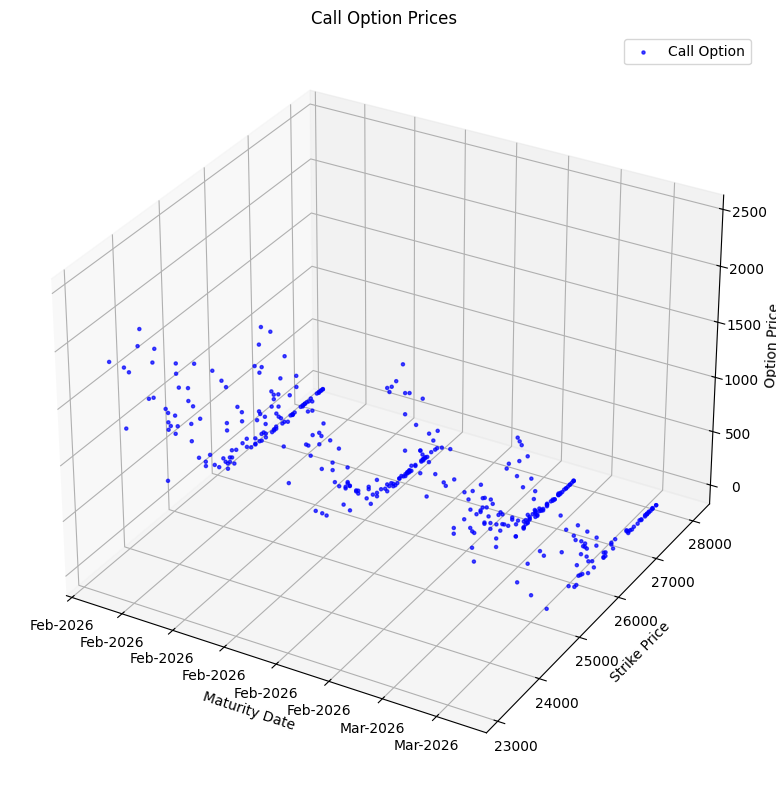

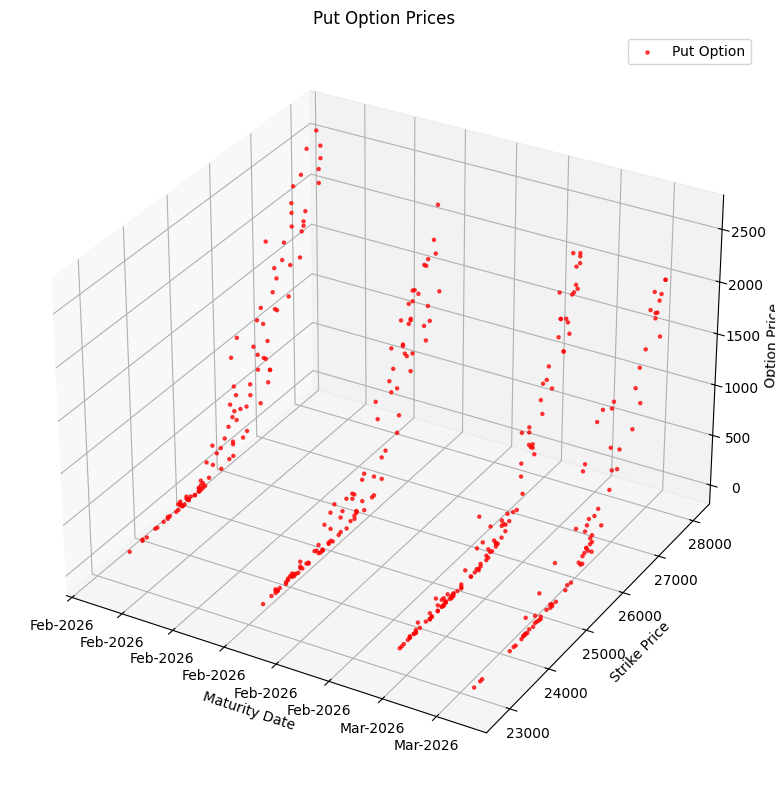

Calculating implied volatilities...
Calculating Call option volatilities...
Processed 15700 options...
Processed 16200 options...
Processed 13400 options...
Processed 8400 options...
Calculating Put option volatilities...
Processed 14500 options...
Processed 15600 options...
Processed 13800 options...
Processed 12800 options...
Processed 7600 options...
Processed 14400 options...
Processed 5300 options...
Processed 5800 options...
Plotting volatility surfaces...


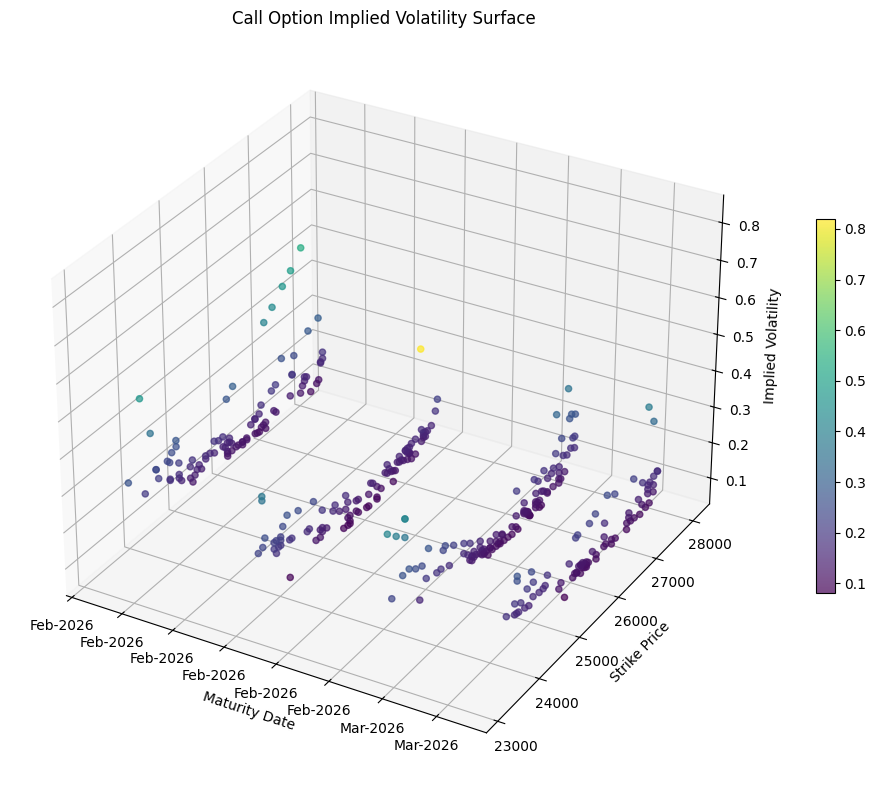

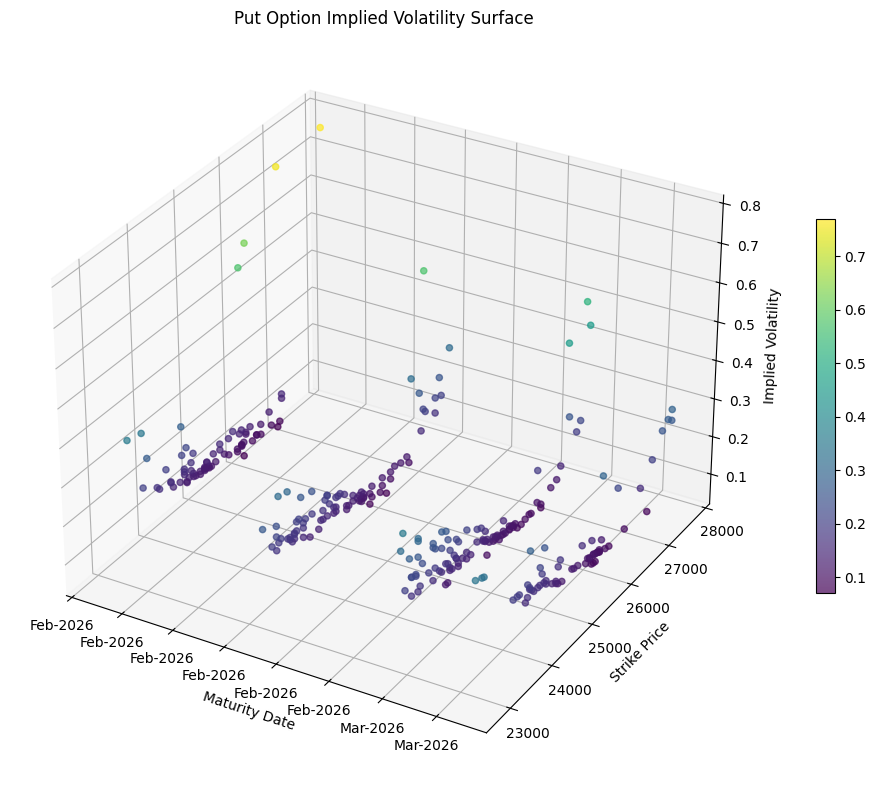

Analysis complete!
Call options volatility statistics:
Mean: 0.1713
Median: 0.1500
Std: 0.0788

Put options volatility statistics:
Mean: 0.1731
Median: 0.1515
Std: 0.0912


In [4]:
#!/usr/bin/env python
# coding: utf-8

from IPython.core.display import display, HTML
import pandas as pd
import numpy as np
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

display(HTML('<h1 style="text-align:center;">MA 374 | Assignment 9</h1>'))
display(HTML('<h2 style="text-align:center;">NIFTY Options Analysis</h2>'))

# Load your data
data = pd.read_csv('NIFTYoptiondata.csv')

# Clean and prepare the data
def prepare_data(df):
    """Prepare the options data for analysis"""

    # Convert date columns to datetime
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')
    df['Expiry'] = pd.to_datetime(df['Expiry'], format='%d-%b-%Y')

    # Calculate time to expiry in years
    df['Time_to_Expiry'] = (df['Expiry'] - df['Date']).dt.days / 365.25

    # Filter out options with very short time to expiry (< 1 day) or very long (> 1 year)
    df = df[(df['Time_to_Expiry'] > 0.003) & (df['Time_to_Expiry'] < 1)]

    # Create separate dataframes for calls and puts
    calls_df = df[df['Option Type'] == 'CE'].copy()
    puts_df = df[df['Option Type'] == 'PE'].copy()

    # Rename LTP column to option prices
    calls_df['Call_Price'] = calls_df['LTP']
    puts_df['Put_Price'] = puts_df['LTP']

    return calls_df, puts_df

# Black-Scholes functions
def getCall(S, K, r, t, sig):
    """Black-Scholes call option price"""
    if t <= 0 or sig <= 0:
        return max(S - K, 0)

    d1 = (np.log(S/K) + t*(r + (sig**2)/2)) / (sig * np.sqrt(t))
    d2 = d1 - sig * np.sqrt(t)
    Nd1 = norm.cdf(d1)
    Nd2 = norm.cdf(d2)
    C = S * Nd1 - K * np.exp(-r*t) * Nd2
    return C

def getPut(S, K, r, t, sig):
    """Black-Scholes put option price"""
    if t <= 0 or sig <= 0:
        return max(K - S, 0)

    d1 = (np.log(S/K) + t*(r + (sig**2)/2)) / (sig * np.sqrt(t))
    d2 = d1 - sig * np.sqrt(t)
    Nd1 = norm.cdf(-d1)
    Nd2 = norm.cdf(-d2)
    P = K * np.exp(-r*t) * Nd2 - S * Nd1
    return P

def objective_function(Price, St, K, r, t, sig, option='Call'):
    """Objective function for volatility calculation"""
    if option == 'Call':
        return getCall(St, K, r, t, sig) - Price
    else:
        return getPut(St, K, r, t, sig) - Price

def calculate_implied_volatility(Price, St, K, r, t, option='Call'):
    """Calculate implied volatility using secant method"""
    if Price <= 0 or St <= 0 or K <= 0 or t <= 0:
        return np.nan

    x0 = 0.1
    x1 = 0.3
    tol = 0.00001
    max_iter = 100
    alpha = 1e-8  # Small number to avoid division by zero

    for i in range(max_iter):
        f0 = objective_function(Price, St, K, r, t, x0, option)
        f1 = objective_function(Price, St, K, r, t, x1, option)

        denominator = f1 - f0 + alpha
        x2 = x1 - f1 * (x1 - x0) / denominator

        # Ensure volatility stays positive and reasonable
        x2 = max(0.01, min(x2, 5.0))

        if abs(objective_function(Price, St, K, r, t, x2, option)) < tol:
            return x2

        x0, x1 = x1, x2

    return np.nan

def calculate_volatilities(df, option_type='Call'):
    """Calculate implied volatilities for all options"""
    volatilities = []
    r = 0.05  # Risk-free rate (5%)

    print(f"Calculating {option_type} option volatilities...")

    for idx, row in df.iterrows():
        St = row['Underlying Value']
        K = row['Strike Price']
        t = row['Time_to_Expiry']

        if option_type == 'Call':
            Price = row['Call_Price']
        else:
            Price = row['Put_Price']

        # Skip if essential data is missing
        if pd.isna(Price) or pd.isna(St) or pd.isna(K) or pd.isna(t):
            volatilities.append(np.nan)
            continue

        vol = calculate_implied_volatility(Price, St, K, r, t, option_type)
        volatilities.append(vol)

        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1} options...")

    return volatilities

def plot_volatility_surface(df, option_type='Call'):
    """Plot 3D volatility surface"""
    # Filter out missing volatilities
    plot_df = df.dropna(subset=['Volatility'])

    if len(plot_df) == 0:
        print(f"No valid volatility data for {option_type} options")
        return

    # Prepare data for plotting
    dates = mdates.date2num(plot_df['Expiry'])
    strikes = plot_df['Strike Price']
    vols = plot_df['Volatility']

    # Create 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(dates, strikes, vols,
                        c=vols, cmap='viridis',
                        s=20, alpha=0.7)

    ax.set_xlabel('Maturity Date')
    ax.set_ylabel('Strike Price')
    ax.set_zlabel('Implied Volatility')
    ax.set_title(f'{option_type} Option Implied Volatility Surface')

    # Format x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

    plt.colorbar(scatter, shrink=0.5)
    plt.tight_layout()
    plt.show()

def plot_option_prices(df, option_type='Call'):
    """Plot 3D option prices surface"""
    if option_type == 'Call':
        price_col = 'Call_Price'
        color = 'blue'
    else:
        price_col = 'Put_Price'
        color = 'red'

    # Filter out missing prices
    plot_df = df.dropna(subset=[price_col])

    if len(plot_df) == 0:
        print(f"No valid price data for {option_type} options")
        return

    dates = mdates.date2num(plot_df['Expiry'])
    strikes = plot_df['Strike Price']
    prices = plot_df[price_col]

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(dates, strikes, prices,
               c=color, marker='.',
               alpha=0.7, label=f'{option_type} Option')

    ax.set_xlabel('Maturity Date')
    ax.set_ylabel('Strike Price')
    ax.set_zlabel('Option Price')
    ax.set_title(f'{option_type} Option Prices')
    ax.legend()

    # Format x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

    plt.tight_layout()
    plt.show()

# Main analysis
print("Preparing data...")
calls_df, puts_df = prepare_data(data)

print(f"Found {len(calls_df)} call options and {len(puts_df)} put options")
print(f"Date range: {calls_df['Date'].min()} to {calls_df['Date'].max()}")
print(f"Underlying price range: {calls_df['Underlying Value'].min():.2f} to {calls_df['Underlying Value'].max():.2f}")

# Sample the data if too large
max_sample_size = 500
if len(calls_df) > max_sample_size:
    calls_sample = calls_df.sample(n=max_sample_size, random_state=42)
    print(f"Sampling {max_sample_size} call options for analysis")
else:
    calls_sample = calls_df

if len(puts_df) > max_sample_size:
    puts_sample = puts_df.sample(n=max_sample_size, random_state=42)
    print(f"Sampling {max_sample_size} put options for analysis")
else:
    puts_sample = puts_df

# Plot option prices
print("Plotting option prices...")
plot_option_prices(calls_sample, 'Call')
plot_option_prices(puts_sample, 'Put')

# Calculate implied volatilities
print("Calculating implied volatilities...")
calls_sample['Volatility'] = calculate_volatilities(calls_sample, 'Call')
puts_sample['Volatility'] = calculate_volatilities(puts_sample, 'Put')

# Plot volatility surfaces
print("Plotting volatility surfaces...")
plot_volatility_surface(calls_sample, 'Call')
plot_volatility_surface(puts_sample, 'Put')

# Save results
calls_result = calls_sample[['Date', 'Expiry', 'Strike Price', 'Call_Price',
                            'Underlying Value', 'Time_to_Expiry', 'Volatility']].copy()
puts_result = puts_sample[['Date', 'Expiry', 'Strike Price', 'Put_Price',
                          'Underlying Value', 'Time_to_Expiry', 'Volatility']].copy()

calls_result.to_csv('call_options_volatility.csv', index=False)
puts_result.to_csv('put_options_volatility.csv', index=False)

print("Analysis complete!")
print(f"Call options volatility statistics:")
print(f"Mean: {calls_sample['Volatility'].mean():.4f}")
print(f"Median: {calls_sample['Volatility'].median():.4f}")
print(f"Std: {calls_sample['Volatility'].std():.4f}")

print(f"\nPut options volatility statistics:")
print(f"Mean: {puts_sample['Volatility'].mean():.4f}")
print(f"Median: {puts_sample['Volatility'].median():.4f}")
print(f"Std: {puts_sample['Volatility'].std():.4f}")

# New Section